In [5]:
import pandas as pd
datos = pd.read_csv('datos_normalizados.csv', sep=';')
datos.head()


,Evasión de clientes,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,Antigüedad del cliente,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,...,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,Cargos mensuales,Gasto total,cuentas_diarias
0,0,0,0,1,1,9,1,0,DSL,0,...,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.186667
1,0,1,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,1.996667
2,1,1,0,0,0,4,1,0,Fiber optic,0,...,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.463333
3,1,1,1,1,0,13,1,0,Fiber optic,0,...,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.266667
4,1,0,1,1,0,3,1,0,Fiber optic,0,...,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.796667


In [6]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Evasión de clientes        7032 non-null   int64  
 1   customer_gender            7032 non-null   int64  
 2   customer_seniorcitizen     7032 non-null   int64  
 3   customer_partner           7032 non-null   int64  
 4   customer_dependents        7032 non-null   int64  
 5   Antigüedad del cliente     7032 non-null   int64  
 6   phone_phoneservice         7032 non-null   int64  
 7   phone_multiplelines        7032 non-null   int64  
 8   internet_internetservice   7032 non-null   str    
 9   internet_onlinesecurity    7032 non-null   int64  
 10  internet_onlinebackup      7032 non-null   int64  
 11  internet_deviceprotection  7032 non-null   int64  
 12  internet_techsupport       7032 non-null   int64  
 13  internet_streamingtv       7032 non-null   int64  
 14  int

In [7]:
X = datos.drop('Evasión de clientes', axis = 1)
y = datos['Evasión de clientes']

In [8]:
X

,customer_gender,customer_seniorcitizen,customer_partner,customer_dependents,Antigüedad del cliente,phone_phoneservice,phone_multiplelines,internet_internetservice,internet_onlinesecurity,internet_onlinebackup,internet_deviceprotection,internet_techsupport,internet_streamingtv,internet_streamingmovies,account_contract,account_paperlessbilling,account_paymentmethod,Cargos mensuales,Gasto total,cuentas_diarias
0,0,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.60,593.30,2.186667
1,1,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.90,542.40,1.996667
2,1,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.90,280.85,2.463333
3,1,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.00,1237.85,3.266667
4,0,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,0,0,0,13,1,0,DSL,1,0,0,1,0,0,One year,0,Mailed check,55.15,742.90,1.838333
7028,1,0,1,0,22,1,1,Fiber optic,0,0,0,0,0,1,Month-to-month,1,Electronic check,85.10,1873.70,2.836667
7029,1,0,0,0,2,1,0,DSL,0,1,0,0,0,0,Month-to-month,1,Mailed check,50.30,92.75,1.676667
7030,1,0,1,1,67,1,0,DSL,1,0,1,1,0,1,Two year,0,Mailed check,67.85,4627.65,2.261667


In [9]:
y

0       0
1       0
2       1
3       1
4       1
       ..
7027    0
7028    1
7029    0
7030    0
7031    0
Name: Evasión de clientes, Length: 7032, dtype: int64

In [2]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

In [10]:
columnas = X.columns

In [11]:
one_hot = make_column_transformer((
    OneHotEncoder(drop = 'if_binary'),
    ['internet_internetservice', 'account_contract', 'account_paymentmethod']
),
    remainder = 'passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False)

In [12]:
X = one_hot.fit_transform(X)

C:\Users\dapar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\compose\_column_transformer.py:978: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


In [13]:
one_hot.get_feature_names_out(columnas)

array(['onehotencoder__internet_internetservice_DSL',
       'onehotencoder__internet_internetservice_Fiber optic',
       'onehotencoder__internet_internetservice_No',
       'onehotencoder__account_contract_Month-to-month',
       'onehotencoder__account_contract_One year',
       'onehotencoder__account_contract_Two year',
       'onehotencoder__account_paymentmethod_Bank transfer (automatic)',
       'onehotencoder__account_paymentmethod_Credit card (automatic)',
       'onehotencoder__account_paymentmethod_Electronic check',
       'onehotencoder__account_paymentmethod_Mailed check',
       'remainder__customer_gender', 'remainder__customer_seniorcitizen',
       'remainder__customer_partner', 'remainder__customer_dependents',
       'remainder__Antigüedad del cliente',
       'remainder__phone_phoneservice', 'remainder__phone_multiplelines',
       'remainder__internet_onlinesecurity',
       'remainder__internet_onlinebackup',
       'remainder__internet_deviceprotection',
     

In [21]:
datos_encoded = pd.DataFrame(X, columns = one_hot.get_feature_names_out(columnas))

In [24]:
datos_encoded.head()

,onehotencoder__internet_internetservice_DSL,onehotencoder__internet_internetservice_Fiber optic,onehotencoder__internet_internetservice_No,onehotencoder__account_contract_Month-to-month,onehotencoder__account_contract_One year,onehotencoder__account_contract_Two year,onehotencoder__account_paymentmethod_Bank transfer (automatic),onehotencoder__account_paymentmethod_Credit card (automatic),onehotencoder__account_paymentmethod_Electronic check,onehotencoder__account_paymentmethod_Mailed check,...,remainder__internet_onlinesecurity,remainder__internet_onlinebackup,remainder__internet_deviceprotection,remainder__internet_techsupport,remainder__internet_streamingtv,remainder__internet_streamingmovies,remainder__account_paperlessbilling,remainder__Cargos mensuales,remainder__Gasto total,remainder__cuentas_diarias
0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,1.0,0.0,1.0,65.6,593.30,2.186667
1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,59.9,542.40,1.996667
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,73.9,280.85,2.463333
3,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,1.0,0.0,1.0,1.0,1.0,98.0,1237.85,3.266667
4,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,1.0,1.0,0.0,1.0,83.9,267.40,2.796667


In [25]:
datos_encoded.columns

Index(['onehotencoder__internet_internetservice_DSL',
       'onehotencoder__internet_internetservice_Fiber optic',
       'onehotencoder__internet_internetservice_No',
       'onehotencoder__account_contract_Month-to-month',
       'onehotencoder__account_contract_One year',
       'onehotencoder__account_contract_Two year',
       'onehotencoder__account_paymentmethod_Bank transfer (automatic)',
       'onehotencoder__account_paymentmethod_Credit card (automatic)',
       'onehotencoder__account_paymentmethod_Electronic check',
       'onehotencoder__account_paymentmethod_Mailed check',
       'remainder__customer_gender', 'remainder__customer_seniorcitizen',
       'remainder__customer_partner', 'remainder__customer_dependents',
       'remainder__Antigüedad del cliente', 'remainder__phone_phoneservice',
       'remainder__phone_multiplelines', 'remainder__internet_onlinesecurity',
       'remainder__internet_onlinebackup',
       'remainder__internet_deviceprotection',
       'rema

In [26]:
datos_encoded["churn"] = y

In [27]:
datos_encoded.rename(columns={"churn": "evasion_clientes"}, inplace=True)

In [23]:
datos['Evasión de clientes'].value_counts()

Evasión de clientes
0    5163
1    1869
Name: count, dtype: int64

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

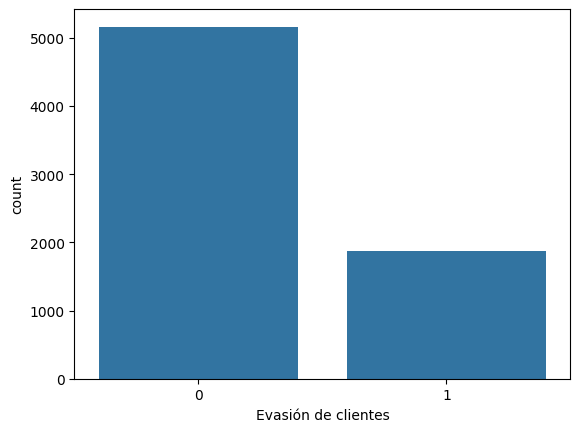

In [17]:
ax = sns.countplot(x = 'Evasión de clientes', data = datos)

In [29]:
corr = datos_encoded.corr()

In [31]:
corr["evasion_clientes"].sort_values()

remainder__Antigüedad del cliente                                -0.354049
onehotencoder__account_contract_Two year                         -0.301552
onehotencoder__internet_internetservice_No                       -0.227578
remainder__Gasto total                                           -0.199484
onehotencoder__account_contract_One year                         -0.178225
remainder__internet_onlinesecurity                               -0.171270
remainder__internet_techsupport                                  -0.164716
remainder__customer_dependents                                   -0.163128
remainder__customer_partner                                      -0.149982
onehotencoder__account_paymentmethod_Credit card (automatic)     -0.134687
onehotencoder__internet_internetservice_DSL                      -0.124141
onehotencoder__account_paymentmethod_Bank transfer (automatic)   -0.118136
onehotencoder__account_paymentmethod_Mailed check                -0.090773
remainder__internet_onlin

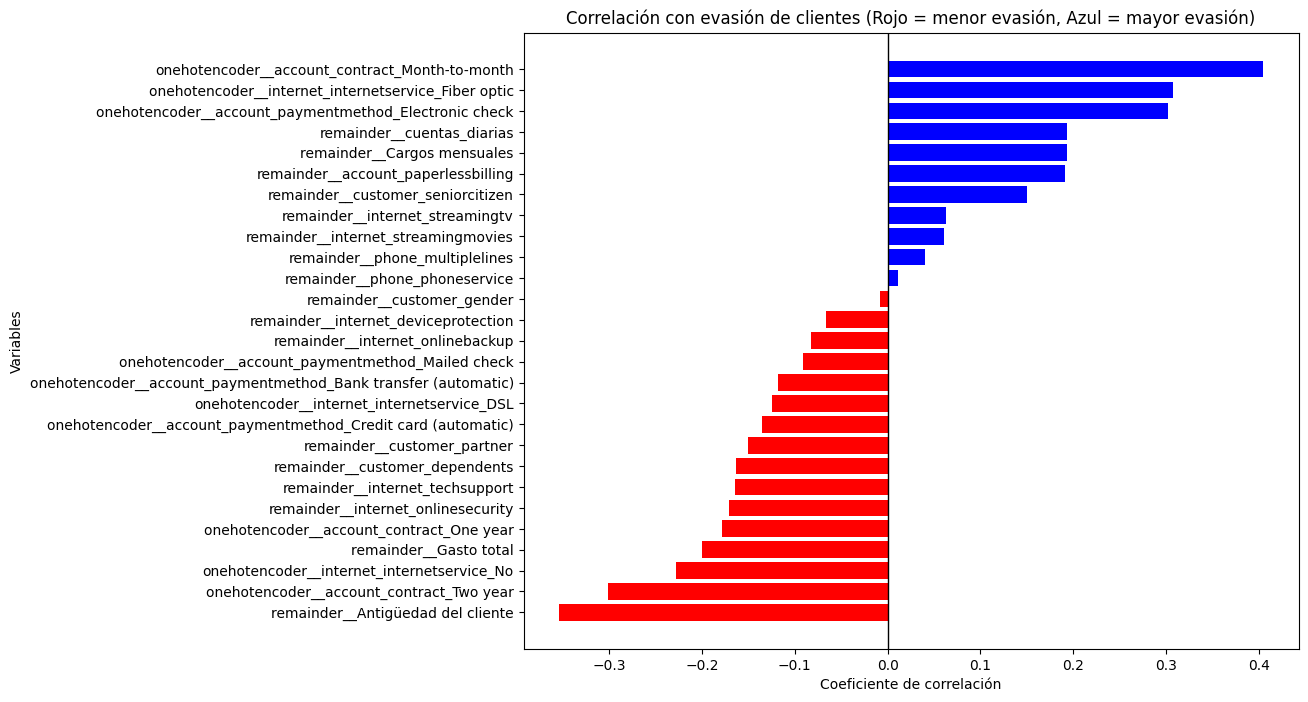

In [42]:
corr_evasion = datos_encoded.corr()["evasion_clientes"].drop("evasion_clientes").sort_values()

colores = ["blue" if x > 0 else "red" for x in corr_evasion]

plt.figure(figsize=(10,8))
plt.barh(corr_evasion.index, corr_evasion.values, color=colores)
plt.xlabel("Coeficiente de correlación")
plt.ylabel("Variables")
plt.title("Correlación con evasión de clientes (Rojo = menor evasión, Azul = mayor evasión)")
plt.axvline(0, color="black", linewidth=1)
plt.show()

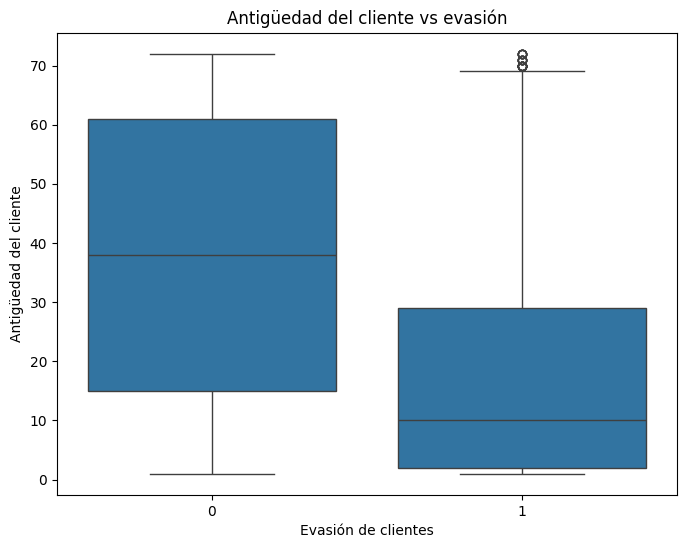

In [43]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="evasion_clientes",
    y="remainder__Antigüedad del cliente",
    data=datos_encoded
)

plt.title("Antigüedad del cliente vs evasión")
plt.xlabel("Evasión de clientes")
plt.ylabel("Antigüedad del cliente")

plt.show()

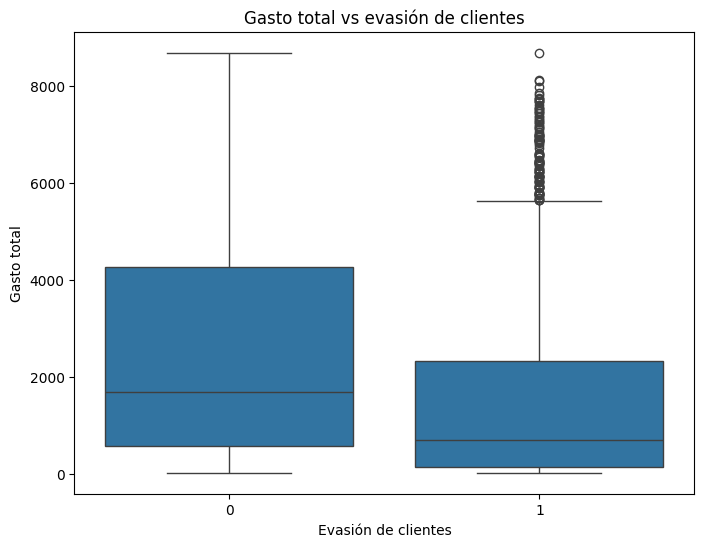

In [44]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="evasion_clientes",
    y="remainder__Gasto total",
    data=datos_encoded
)

plt.title("Gasto total vs evasión de clientes")
plt.xlabel("Evasión de clientes")
plt.ylabel("Gasto total")

plt.show()

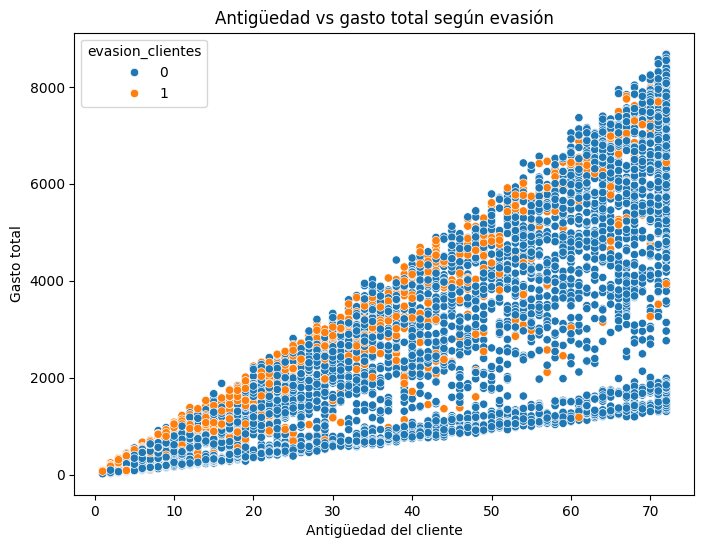

In [45]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="remainder__Antigüedad del cliente",
    y="remainder__Gasto total",
    hue="evasion_clientes",
    data=datos_encoded
)

plt.title("Antigüedad vs gasto total según evasión")
plt.xlabel("Antigüedad del cliente")
plt.ylabel("Gasto total")

plt.show()

In [47]:
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify = y,  random_state = 5)

In [50]:
from sklearn.dummy import DummyClassifier

In [51]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)
print(dummy.score(X_test, y_test))

0.7343572241183163


In [52]:
from sklearn.tree import DecisionTreeClassifier

In [53]:
modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_arbol.fit(X_train, y_train)
print(modelo_arbol.score(X_test, y_test))

0.7246871444823664


In [54]:
dummy = DummyClassifier()
dummy.fit(X_train, y_train)
print("Dummy:", dummy.score(X_test, y_test))

modelo_arbol = DecisionTreeClassifier(random_state=42)
modelo_arbol.fit(X_train, y_train)
print("Árbol:", modelo_arbol.score(X_test, y_test))

Dummy: 0.7343572241183163
Árbol: 0.7246871444823664


In [55]:
from sklearn.ensemble import RandomForestClassifier

In [57]:
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)
print("RF:",modelo_rf.score(X_test, y_test))

RF: 0.7889647326507395


In [58]:
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=datos_encoded.drop("evasion_clientes", axis=1).columns
)

importancias = importancias.sort_values(ascending=False)

print(importancias.head(10))

remainder__Gasto total                                   0.156322
remainder__Antigüedad del cliente                        0.142577
remainder__Cargos mensuales                              0.133272
remainder__cuentas_diarias                               0.130673
onehotencoder__account_contract_Month-to-month           0.067229
onehotencoder__internet_internetservice_Fiber optic      0.033763
onehotencoder__account_paymentmethod_Electronic check    0.030098
remainder__customer_gender                               0.023818
onehotencoder__account_contract_Two year                 0.023653
remainder__account_paperlessbilling                      0.023501
dtype: float64


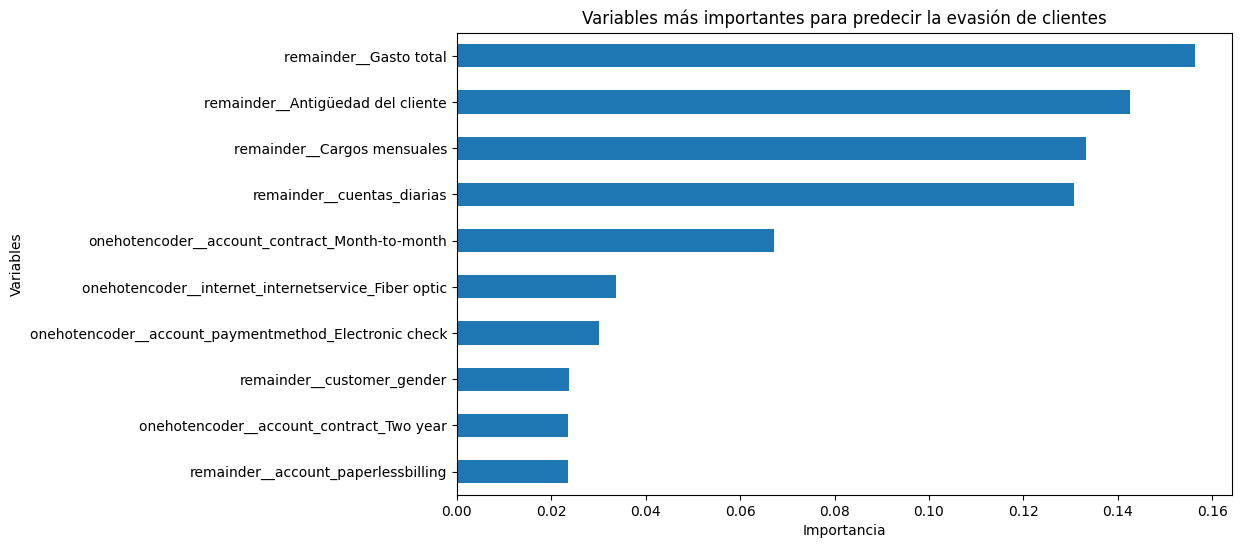

In [59]:
import matplotlib.pyplot as plt

top_vars = importancias.head(10)

plt.figure(figsize=(10,6))
top_vars.sort_values().plot(kind="barh")

plt.title("Variables más importantes para predecir la evasión de clientes")
plt.xlabel("Importancia")
plt.ylabel("Variables")

plt.show()

El modelo RandomForestClassifier permite identificar la importancia relativa de cada variable en la predicción de la evasión de clientes. Los resultados muestran que variables como los cargos mensuales, la antigüedad del cliente, el tipo de contrato y el servicio de internet tienen un impacto significativo en la predicción. Esto indica que factores relacionados con el costo del servicio y la duración del contrato influyen de manera importante en la probabilidad de cancelación.

# Informe de análisis de cancelación de clientes
## Objetivo

El objetivo de este análisis fue identificar los factores que influyen en la cancelación de clientes y evaluar distintos modelos de clasificación para predecir este comportamiento.

## Análisis exploratorio

El análisis de correlación permitió identificar variables asociadas a la cancelación. Entre las variables con mayor relación positiva con la evasión se encuentran:

- Contrato Month-to-month

- Internet Fiber optic

- Método de pago Electronic check

- Cargos mensuales

- Facturación sin papel

Estas variables sugieren una mayor probabilidad de cancelación.

Por otro lado, las variables con correlación negativa incluyen:

- Antigüedad del cliente

- Contratos de uno o dos años

- Gasto total

- Servicios adicionales como online security y tech support

Esto indica que clientes con mayor permanencia, contratos de largo plazo y servicios complementarios tienden a cancelar menos.

## Modelos utilizados

Se evaluaron tres modelos de clasificación:

DummyClassifier, utilizado como modelo base de referencia.

DecisionTreeClassifier, modelo basado en árboles de decisión.

RandomForestClassifier, modelo que combina múltiples árboles para mejorar la predicción.

Resultados de los modelos
Modelo	Accuracy
DummyClassifier	0.73
DecisionTreeClassifier	0.72
RandomForestClassifier	0.78

El DummyClassifier refleja la proporción de la clase mayoritaria en el dataset.
El árbol de decisión no logró superar el desempeño del modelo base.
El Random Forest obtuvo el mejor rendimiento, alcanzando una precisión de 0.78, lo que indica una mejor capacidad para identificar patrones asociados a la cancelación.

## Factores principales de cancelación

Los factores más relevantes identificados fueron:

- Contrato mes a mes

- Baja antigüedad del cliente

- Altos cargos mensuales

- Internet por fibra óptica

- Método de pago Electronic check

En contraste, los contratos de largo plazo, mayor antigüedad y servicios adicionales de soporte o seguridad se asocian con menor cancelación.

## Estrategias de retención propuestas

A partir de los resultados se sugieren las siguientes estrategias:

- Incentivar contratos de largo plazo mediante descuentos o beneficios.

- Fortalecer la retención de clientes nuevos, especialmente durante los primeros meses.

- Revisar la estructura de precios en planes con cargos mensuales altos.

- Mejorar la experiencia del servicio de fibra óptica.

- Promover métodos de pago automáticos.

- Ofrecer servicios adicionales como soporte técnico y seguridad online.

## Conclusión

El modelo RandomForestClassifier presentó el mejor desempeño en la predicción de cancelación de clientes. El análisis muestra que factores como el tipo de contrato, la antigüedad del cliente y el costo del servicio influyen significativamente en la probabilidad de evasión. Implementar estrategias orientadas a fidelizar clientes y mejorar la percepción de valor del servicio puede contribuir a reducir la cancelación.